# TrenMax - Data Cleaning & Exploratory Data Analysis

## Contexto

TrenMax es una empresa recién llegada a España que obtuvo la licencia para operar trenes en el país. Para preparar una estrategia de precios competitiva, la empresa cuenta con un dataset histórico de viajes ofrecidos por la competencia.

El dataset contiene información de rutas, fechas de consulta, fechas de viaje, tipo de tren, tarifa, clase y precio ofertado.

## Objetivo del notebook

El objetivo de este notebook es construir un dataset limpio, consistente y enriquecido que pueda utilizarse posteriormente para entrenar un modelo predictivo de precios.

La variable objetivo será:

- `PRECIO`

Las principales variables explicativas serán:

- Ruta del viaje
- Tipo de tren
- Tipo de tarifa
- Clase
- Duración del viaje
- Anticipación de compra
- Día, mes y horario de salida


## 1. Importación de librerías


In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

sns.set_theme(style='whitegrid')


## 2. Carga del dataset


In [97]:
# Cargar dataset
DATA_PATH = 'renfe.csv'

df_raw = pd.read_csv(DATA_PATH, sep=',', encoding='latin-1')

# Copia de trabajo para preservar el dataset original
df = df_raw.copy()

df.head()


,FECHA_CONSULTA,FECHA_INICIO,FECHA_FIN,CIUDAD_ORIGEN,CIUDAD_DESTINO,TIPO_TREN,TIPO_TARIFA,CLASE,PRECIO
0,2019-05-25 01:43:03,2019-06-28 20:36:00,2019-06-28 23:14:00,SEVILLA,MADRID,ALVIA,Flexible,Turista,67.20
1,2019-06-22 13:05:11,2019-07-14 10:00:00,2019-07-14 13:10:00,BARCELONA,MADRID,AVE,Flexible,Turista,107.70
2,2019-04-17 06:24:03,2019-05-23 13:40:00,2019-05-23 16:10:00,SEVILLA,MADRID,AVE,Promo,Turista,47.30
3,2019-05-10 21:21:59,2019-05-29 14:50:00,2019-05-29 22:30:00,VALENCIA,MADRID,REGIONAL,Adulto ida,Turista,28.35
4,2019-05-09 19:43:37,2019-06-26 13:25:00,2019-06-26 16:24:00,MADRID,BARCELONA,AVE-TGV,Promo,Turista,66.75


In [98]:
# Dimensiones iniciales del dataset
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]:,}')


Rows: 383,568
Columns: 9


In [99]:
# Información general
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383568 entries, 0 to 383567
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   FECHA_CONSULTA  383568 non-null  object 
 1   FECHA_INICIO    383568 non-null  object 
 2   FECHA_FIN       383568 non-null  object 
 3   CIUDAD_ORIGEN   383568 non-null  object 
 4   CIUDAD_DESTINO  383568 non-null  object 
 5   TIPO_TREN       345211 non-null  object 
 6   TIPO_TARIFA     344009 non-null  object 
 7   CLASE           344000 non-null  object 
 8   PRECIO          355038 non-null  float64
dtypes: float64(1), object(8)
memory usage: 26.3+ MB


## 3. Exploración inicial

Antes de limpiar el dataset, revisamos columnas, tipos de datos, valores nulos, duplicados y primeras métricas generales.


In [100]:
# Columnas disponibles
df.columns.tolist()


['FECHA_CONSULTA',
 'FECHA_INICIO',
 'FECHA_FIN',
 'CIUDAD_ORIGEN',
 'CIUDAD_DESTINO',
 'TIPO_TREN',
 'TIPO_TARIFA',
 'CLASE',
 'PRECIO']

In [101]:
# Estadísticas descriptivas para variables numéricas
df.describe()


,PRECIO
count,"355,038.00"
mean,61.44
std,25.70
min,0.00
25%,41.20
50%,58.15
75%,76.30
max,342.80


In [102]:
# Estadísticas descriptivas para variables categóricas
df.describe(include='object')


,FECHA_CONSULTA,FECHA_INICIO,FECHA_FIN,CIUDAD_ORIGEN,CIUDAD_DESTINO,TIPO_TREN,TIPO_TARIFA,CLASE
count,383568,383568,383568,383568,383568,345211,344009,344000
unique,226818,18161,23200,5,5,16,10,9
top,2019-06-02 11:01:46,2019-06-02 17:30:00,2019-05-30 14:20:00,MADRID,MADRID,AVE,Promo,Turista
freq,13,185,111,191663,191905,236293,239847,261745


## 4. Calidad de datos

Creamos una tabla resumen para evaluar valores nulos, cantidad de valores únicos y tipos de datos por columna.


In [103]:
quality_summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'null_count': df.isnull().sum(),
    'null_percentage': (df.isnull().mean() * 100).round(2),
    'unique_values': df.nunique(dropna=False)
}).sort_values('null_percentage', ascending=False)

quality_summary


,dtype,null_count,null_percentage,unique_values
CLASE,object,39568,10.32,10
TIPO_TARIFA,object,39559,10.31,11
TIPO_TREN,object,38357,10.00,17
PRECIO,float64,28530,7.44,293
FECHA_CONSULTA,object,0,0.00,226818
FECHA_INICIO,object,0,0.00,18161
FECHA_FIN,object,0,0.00,23200
CIUDAD_ORIGEN,object,0,0.00,5
CIUDAD_DESTINO,object,0,0.00,5


In [104]:
# Duplicados exactos
duplicated_rows = df.duplicated().sum()
print(f'Duplicated rows: {duplicated_rows:,}')

# Muestra de duplicados, si existen
df[df.duplicated()].head()


Duplicated rows: 24


,FECHA_CONSULTA,FECHA_INICIO,FECHA_FIN,CIUDAD_ORIGEN,CIUDAD_DESTINO,TIPO_TREN,TIPO_TARIFA,CLASE,PRECIO
67494,2019-04-29 23:15:13,2019-05-14 06:20:00,2019-05-14 14:25:00,MADRID,BARCELONA,LD-AVE,Promo,Turista,NaN
82429,2019-04-30 09:09:51,2019-05-19 17:30:00,2019-05-19 19:43:00,VALENCIA,MADRID,INTERCITY,Flexible,Turista,55.40
88401,2019-05-15 23:37:01,2019-06-21 21:05:00,2019-06-21 23:32:00,VALENCIA,MADRID,INTERCITY,NaN,NaN,NaN
107458,2019-06-12 11:51:44,2019-06-16 17:30:00,2019-06-16 19:43:00,VALENCIA,MADRID,INTERCITY,Flexible,TuristaSólo plaza H,55.40
143395,2019-08-17 03:22:19,2019-09-01 21:03:00,2019-09-01 23:28:00,VALENCIA,MADRID,INTERCITY,Flexible,Turista,NaN


### Conclusión inicial sobre calidad de datos

- Las columnas categóricas `TIPO_TREN`, `TIPO_TARIFA` y `CLASE` tienen valores nulos.
- La variable objetivo `PRECIO` también tiene valores nulos, por lo que esos registros no serán útiles para entrenar un modelo supervisado de predicción de precios.
- Existen algunos duplicados exactos que conviene eliminar.
- Las fechas vienen como texto y deben convertirse a formato datetime.


## 5. Conversión de fechas

Convertimos las columnas de fecha a tipo `datetime`. En esta etapa conservamos las columnas originales transformadas, porque serán útiles para validar el dataset y construir nuevas variables.


In [105]:
date_columns = ['FECHA_CONSULTA', 'FECHA_INICIO', 'FECHA_FIN']

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df[date_columns].dtypes


FECHA_CONSULTA    datetime64[ns]
FECHA_INICIO      datetime64[ns]
FECHA_FIN         datetime64[ns]
dtype: object

In [106]:
# Verificar si aparecieron fechas inválidas luego de la conversión
df[date_columns].isnull().sum()


FECHA_CONSULTA    0
FECHA_INICIO      0
FECHA_FIN         0
dtype: int64

## 6. Limpieza de duplicados

Eliminamos duplicados exactos y usamos `.copy()` para evitar warnings de asignación encadenada (`SettingWithCopyWarning`).


In [107]:
df = df.drop_duplicates().copy()

print(f'Rows after removing duplicates: {df.shape[0]:,}')
print(f'Duplicated rows remaining: {df.duplicated().sum():,}')


Rows after removing duplicates: 383,544
Duplicated rows remaining: 0


## 7. Feature engineering

Construimos nuevas variables que pueden explicar mejor el precio del billete.


In [108]:
# Ruta del viaje
df['RUTA'] = df['CIUDAD_ORIGEN'] + ' - ' + df['CIUDAD_DESTINO']

# Duración del viaje en minutos
df['DURACION_VIAJE_MIN'] = ((
    df['FECHA_FIN'] - df['FECHA_INICIO']
) / np.timedelta64(1, 'm'))

# Anticipación de compra / consulta respecto del inicio del viaje
df['ANTICIPACION_COMPRA_MIN'] = (
    df['FECHA_INICIO'] - df['FECHA_CONSULTA']
)/ np.timedelta64(1, 'm')

df['ANTICIPACION_COMPRA_DIAS'] = df['ANTICIPACION_COMPRA_MIN'] / 1440

# Variables temporales de salida
df['HORA_SALIDA'] = df['FECHA_INICIO'].dt.hour
df['DIA_SEMANA_SALIDA'] = df['FECHA_INICIO'].dt.day_name()
df['DIA_SEMANA_NUM'] = df['FECHA_INICIO'].dt.dayofweek
df['MES_SALIDA'] = df['FECHA_INICIO'].dt.month
df['ES_FIN_DE_SEMANA'] = df['DIA_SEMANA_NUM'].isin([5, 6]).astype(int)

df.head()


,FECHA_CONSULTA,FECHA_INICIO,FECHA_FIN,CIUDAD_ORIGEN,CIUDAD_DESTINO,TIPO_TREN,TIPO_TARIFA,CLASE,PRECIO,RUTA,DURACION_VIAJE_MIN,ANTICIPACION_COMPRA_MIN,ANTICIPACION_COMPRA_DIAS,HORA_SALIDA,DIA_SEMANA_SALIDA,DIA_SEMANA_NUM,MES_SALIDA,ES_FIN_DE_SEMANA
0,2019-05-25 01:43:03,2019-06-28 20:36:00,2019-06-28 23:14:00,SEVILLA,MADRID,ALVIA,Flexible,Turista,67.20,SEVILLA - MADRID,158.00,"50,092.95",34.79,20,Friday,4,6,0
1,2019-06-22 13:05:11,2019-07-14 10:00:00,2019-07-14 13:10:00,BARCELONA,MADRID,AVE,Flexible,Turista,107.70,BARCELONA - MADRID,190.00,"31,494.82",21.87,10,Sunday,6,7,1
2,2019-04-17 06:24:03,2019-05-23 13:40:00,2019-05-23 16:10:00,SEVILLA,MADRID,AVE,Promo,Turista,47.30,SEVILLA - MADRID,150.00,"52,275.95",36.30,13,Thursday,3,5,0
3,2019-05-10 21:21:59,2019-05-29 14:50:00,2019-05-29 22:30:00,VALENCIA,MADRID,REGIONAL,Adulto ida,Turista,28.35,VALENCIA - MADRID,460.00,"26,968.02",18.73,14,Wednesday,2,5,0
4,2019-05-09 19:43:37,2019-06-26 13:25:00,2019-06-26 16:24:00,MADRID,BARCELONA,AVE-TGV,Promo,Turista,66.75,MADRID - BARCELONA,179.00,"68,741.38",47.74,13,Wednesday,2,6,0


## 8. Limpieza de variables categóricas

Normalizamos columnas de texto para evitar inconsistencias por espacios, mayúsculas/minúsculas o valores faltantes.

In [109]:
text_columns = ['CIUDAD_ORIGEN', 'CIUDAD_DESTINO', 'TIPO_TREN', 'TIPO_TARIFA', 'CLASE']

for col in text_columns:
    df[col] = df[col].astype('string').str.strip().str.upper()

df[text_columns].head()

,CIUDAD_ORIGEN,CIUDAD_DESTINO,TIPO_TREN,TIPO_TARIFA,CLASE
0,SEVILLA,MADRID,ALVIA,FLEXIBLE,TURISTA
1,BARCELONA,MADRID,AVE,FLEXIBLE,TURISTA
2,SEVILLA,MADRID,AVE,PROMO,TURISTA
3,VALENCIA,MADRID,REGIONAL,ADULTO IDA,TURISTA
4,MADRID,BARCELONA,AVE-TGV,PROMO,TURISTA


In [110]:
def fill_with_group_mode(df, target_col, group_cols):
    """
    Rellena nulos de una columna categórica usando la moda
    dentro de grupos definidos por otras columnas.
    """
    df = df.copy()

    mode_by_group = (
        df.dropna(subset=[target_col])
          .groupby(group_cols)[target_col]
          .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    )

    mapped_values = df.set_index(group_cols).index.map(mode_by_group)

    mapped_series = pd.Series(mapped_values, index=df.index)

    df[target_col] = df[target_col].fillna(mapped_series)

    return df

In [111]:
# Reemplazar nulos en variables categóricas por una categoría explícita
categorical_columns_with_na = ['TIPO_TREN', 'TIPO_TARIFA', 'CLASE']

group_cols = ['CIUDAD_ORIGEN', 'CIUDAD_DESTINO', 'DURACION_VIAJE_MIN']

df = fill_with_group_mode(df, 'TIPO_TREN', group_cols)
df = fill_with_group_mode(df, 'CLASE', group_cols)
df = fill_with_group_mode(df, 'TIPO_TARIFA', group_cols)

df[categorical_columns_with_na].isnull().sum()

TIPO_TREN      0
TIPO_TARIFA    0
CLASE          0
dtype: int64

### Justificación

Para las variables categóricas, no eliminamos los registros con valores nulos porque pueden seguir aportando información valiosa al análisis. En su lugar, tomamos `LA MODA` de cada categoría usando solo como columnas de agrupación `CIUDAD_ORIGEN`, `CIUDAD_DESTINO`, `DURACION_VIAJE_MIN`.

En cambio, para `PRECIO`, al ser la variable objetivo, los registros sin precio se excluirán más adelante del dataset final de modelado.

## 9. Agrupación de tarifas

Agrupamos `TIPO_TARIFA` para reducir cardinalidad y mejorar la interpretación del análisis. La categoría `ADULTO IDA` se interpreta como una tarifa estándar, no como una promoción.


In [112]:
df['TIPO_TARIFA_AGRUPADA'] = np.select(
    [
        df['TIPO_TARIFA'].eq('DESCONOCIDO'),
        df['TIPO_TARIFA'].str.contains('PROMO', na=False),
        df['TIPO_TARIFA'].str.contains('FLEXIBLE', na=False),
        df['TIPO_TARIFA'].str.contains('ADULTO', na=False),
    ],
    [
        'DESCONOCIDO',
        'PROMO',
        'FLEXIBLE',
        'STANDARD',
    ],
    default='OTRAS'
)

df[['TIPO_TARIFA', 'TIPO_TARIFA_AGRUPADA']].drop_duplicates().sort_values('TIPO_TARIFA_AGRUPADA')


,TIPO_TARIFA,TIPO_TARIFA_AGRUPADA
0,FLEXIBLE,FLEXIBLE
54747,INDIVIDUAL-FLEXIBLE,FLEXIBLE
320114,DOBLE FAMILIAR-FLEXIBLE,FLEXIBLE
16565,MESA,OTRAS
121961,4X100,OTRAS
302866,GRUPOS IDA,OTRAS
2,PROMO,PROMO
41,PROMO +,PROMO
4326,COD.PROMOCIONAL,PROMO
3,ADULTO IDA,STANDARD


In [113]:
df['TIPO_TARIFA_AGRUPADA'].value_counts(dropna=False)


TIPO_TARIFA_AGRUPADA
PROMO       282408
FLEXIBLE     77183
STANDARD     23943
OTRAS           10
Name: count, dtype: int64

## 10. Validaciones de negocio

Revisamos posibles inconsistencias:

- Duraciones negativas o iguales a cero.
- Consultas realizadas después del inicio del viaje.
- Precios nulos o iguales a cero.
- Valores extremos en duración, anticipación y precio.


In [114]:
validation_summary = {
    'duracion_viaje_min_menor_o_igual_0': (df['DURACION_VIAJE_MIN'] <= 0).sum(),
    'anticipacion_compra_min_menor_0': (df['ANTICIPACION_COMPRA_MIN'] < 0).sum(),
    'precio_nulo': df['PRECIO'].isnull().sum(),
    'precio_menor_o_igual_0': (df['PRECIO'] <= 0).sum()
}

pd.Series(validation_summary).to_frame('count')


,count
duracion_viaje_min_menor_o_igual_0,0
anticipacion_compra_min_menor_0,671
precio_nulo,28516
precio_menor_o_igual_0,2


In [115]:
# Revisar registros con anticipación negativa
negative_anticipation = df[df['ANTICIPACION_COMPRA_MIN'] < 0]
negative_anticipation.head()


,FECHA_CONSULTA,FECHA_INICIO,FECHA_FIN,CIUDAD_ORIGEN,CIUDAD_DESTINO,TIPO_TREN,TIPO_TARIFA,CLASE,PRECIO,RUTA,DURACION_VIAJE_MIN,ANTICIPACION_COMPRA_MIN,ANTICIPACION_COMPRA_DIAS,HORA_SALIDA,DIA_SEMANA_SALIDA,DIA_SEMANA_NUM,MES_SALIDA,ES_FIN_DE_SEMANA,TIPO_TARIFA_AGRUPADA
381,2019-08-22 01:08:54,2019-08-21 08:30:00,2019-08-21 11:14:00,MADRID,SEVILLA,ALVIA,PROMO,TURISTA,NaN,MADRID - SEVILLA,164.00,-998.90,-0.69,8,Wednesday,2,8,0,PROMO
792,2019-08-14 11:32:57,2019-08-05 18:35:00,2019-08-05 21:08:00,MADRID,SEVILLA,ALVIA,FLEXIBLE,PREFERENTESÓLO PLAZA H,87.40,MADRID - SEVILLA,153.00,"-12,537.95",-8.71,18,Monday,0,8,0,FLEXIBLE
956,2019-05-28 01:11:40,2019-05-27 20:35:00,2019-05-27 23:15:00,MADRID,SEVILLA,AVE,PROMO,TURISTA PLUS,72.30,MADRID - SEVILLA,160.00,-276.67,-0.19,20,Monday,0,5,0,PROMO
1063,2019-08-14 11:37:44,2019-08-07 22:14:00,2019-08-08 04:31:00,MADRID,PONFERRADA,TRENHOTEL,FLEXIBLE,TURISTA,NaN,MADRID - PONFERRADA,377.00,"-9,443.73",-6.56,22,Wednesday,2,8,0,FLEXIBLE
1372,2019-06-11 01:11:48,2019-06-10 13:10:00,2019-06-10 20:51:00,MADRID,SEVILLA,MD-LD,FLEXIBLE,TURISTA CON ENLACE,45.80,MADRID - SEVILLA,461.00,-721.80,-0.50,13,Monday,0,6,0,FLEXIBLE


In [116]:
# Distribución rápida de variables numéricas creadas
numeric_features = ['PRECIO', 'DURACION_VIAJE_MIN', 'ANTICIPACION_COMPRA_MIN']
df[numeric_features].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])


,PRECIO,DURACION_VIAJE_MIN,ANTICIPACION_COMPRA_MIN
count,"355,028.00","383,544.00","383,544.00"
mean,61.44,186.92,"37,292.68"
std,25.70,94.89,"23,051.07"
min,0.00,98.00,"-48,747.83"
1%,21.95,100.00,694.78
5%,27.80,100.00,"3,505.91"
25%,41.20,150.00,"17,811.05"
50%,58.15,158.00,"35,485.21"
75%,76.30,190.00,"55,195.22"
95%,107.70,415.00,"77,884.40"


### Decisiones de limpieza para modelado

Para construir el dataset final de modelado:

- Eliminamos registros sin `PRECIO`, porque es la variable objetivo.
- Eliminamos registros con `PRECIO <= 0`, ya que no representan un precio válido para entrenar el modelo.
- Eliminamos viajes con duración inválida.
- Eliminamos registros donde la consulta ocurre después del inicio del viaje, porque generan una anticipación negativa.


In [117]:
df_model = df.copy()

initial_rows = df_model.shape[0]

df_model = df_model[df_model['PRECIO'].notna()].copy()
df_model = df_model[df_model['PRECIO'] > 0].copy()
df_model = df_model[df_model['DURACION_VIAJE_MIN'] > 0].copy()
df_model = df_model[df_model['ANTICIPACION_COMPRA_MIN'] >= 0].copy()

final_rows = df_model.shape[0]
removed_rows = initial_rows - final_rows

print(f'Initial rows: {initial_rows:,}')
print(f'Final model rows: {final_rows:,}')
print(f'Removed rows: {removed_rows:,}')
print(f'Removed percentage: {removed_rows / initial_rows:.2%}')


Initial rows: 383,544
Final model rows: 354,513
Removed rows: 29,031
Removed percentage: 7.57%


## 11. Análisis exploratorio del precio

Analizamos la variable objetivo `PRECIO` y su relación con las principales variables explicativas.


In [118]:
df_model['PRECIO'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])


count   354,513.00
mean         61.41
std          25.67
min          12.85
1%           21.95
5%           27.80
25%          41.20
50%          58.15
75%          76.30
95%         107.70
99%         127.10
max         342.80
Name: PRECIO, dtype: float64

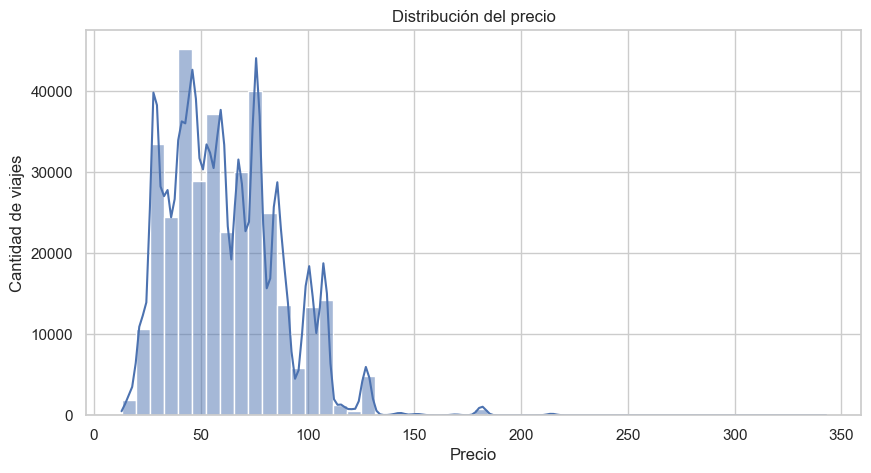

In [119]:
plt.figure(figsize=(10, 5))
sns.histplot(df_model['PRECIO'], bins=50, kde=True)
plt.title('Distribución del precio')
plt.xlabel('Precio')
plt.ylabel('Cantidad de viajes')
plt.show()


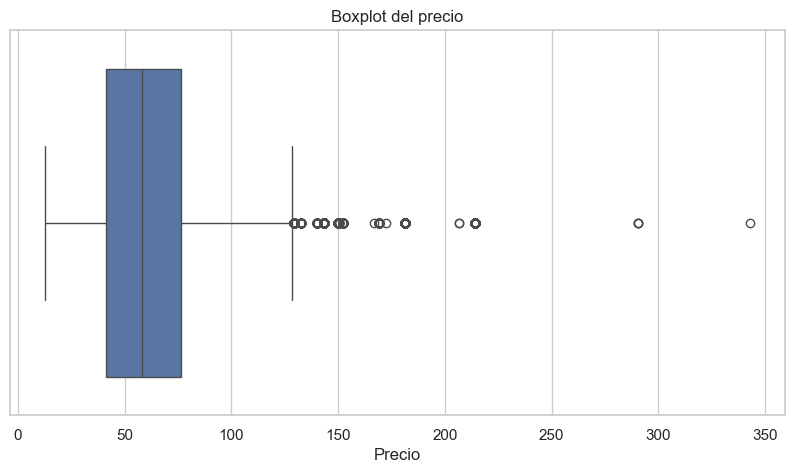

In [120]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_model, x='PRECIO')
plt.title('Boxplot del precio')
plt.xlabel('Precio')
plt.show()


### Precio por ruta


In [121]:
price_by_route = (
    df_model
    .groupby('RUTA')
    .agg(
        cantidad=('PRECIO', 'count'),
        precio_medio=('PRECIO', 'mean'),
        precio_mediano=('PRECIO', 'median'),
        precio_minimo=('PRECIO', 'min'),
        precio_maximo=('PRECIO', 'max')
    )
    .sort_values('precio_mediano', ascending=False)
)

price_by_route


,cantidad,precio_medio,precio_mediano,precio_minimo,precio_maximo
RUTA,,,,,
BARCELONA - MADRID,59720,85.62,85.10,32.30,214.20
MADRID - BARCELONA,60587,86.57,85.10,32.30,342.80
MADRID - SEVILLA,52972,58.43,60.30,18.65,166.60
SEVILLA - MADRID,53577,56.94,53.40,18.65,128.50
MADRID - PONFERRADA,8378,45.02,45.80,16.75,150.60
PONFERRADA - MADRID,12725,43.17,45.80,16.75,150.60
MADRID - VALENCIA,54588,41.46,39.45,12.85,123.20
VALENCIA - MADRID,51966,39.94,34.35,12.85,123.20


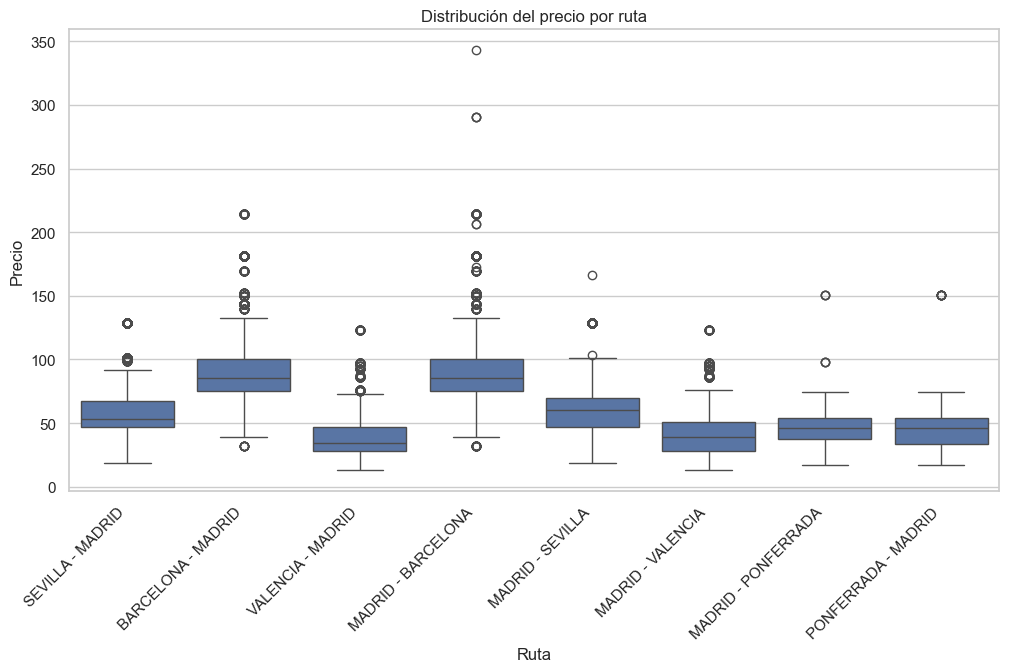

In [122]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_model, x='RUTA', y='PRECIO')
plt.title('Distribución del precio por ruta')
plt.xlabel('Ruta')
plt.ylabel('Precio')
plt.xticks(rotation=45, ha='right')
plt.show()


### Precio por tipo de tren


In [123]:
price_by_train_type = (
    df_model
    .groupby('TIPO_TREN')
    .agg(
        cantidad=('PRECIO', 'count'),
        precio_medio=('PRECIO', 'mean'),
        precio_mediano=('PRECIO', 'median')
    )
    .sort_values('precio_mediano', ascending=False)
)

price_by_train_type


,cantidad,precio_medio,precio_mediano
TIPO_TREN,,,
AVE-TGV,4907,90.45,85.10
AVE,251354,67.97,66.75
AVE-MD,2633,56.77,59.60
ALVIA,21501,55.78,55.80
MD,546,52.50,52.50
AV CITY,9947,47.30,49.15
LD,4010,46.66,47.00
TRENHOTEL,4201,47.89,45.80
R. EXPRES,4597,43.25,43.25


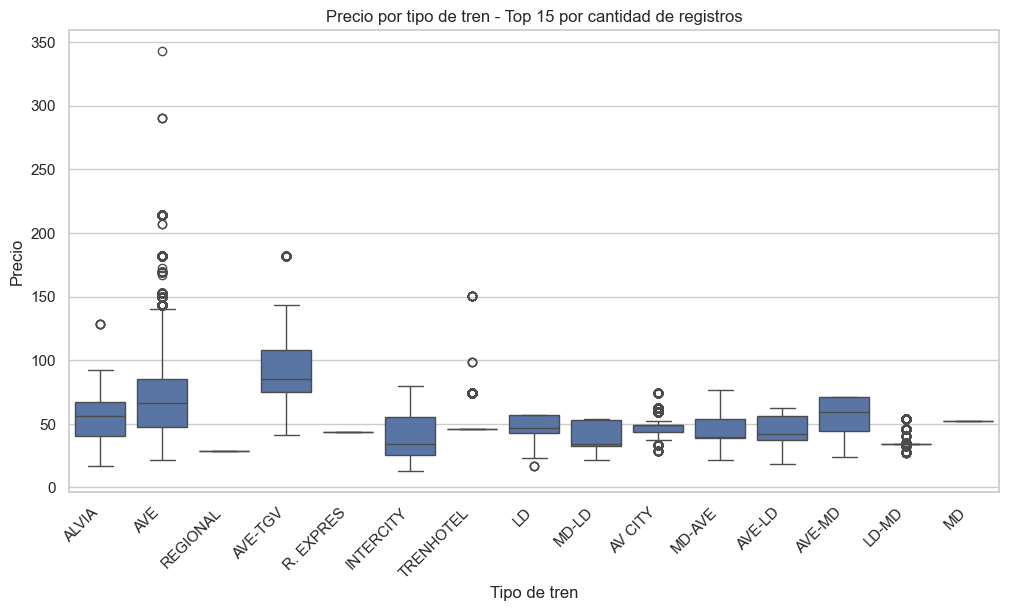

In [124]:
top_train_types = df_model['TIPO_TREN'].value_counts().head(15).index

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_model[df_model['TIPO_TREN'].isin(top_train_types)], x='TIPO_TREN', y='PRECIO')
plt.title('Precio por tipo de tren - Top 15 por cantidad de registros')
plt.xlabel('Tipo de tren')
plt.ylabel('Precio')
plt.xticks(rotation=45, ha='right')
plt.show()


### Precio por tarifa agrupada


In [125]:
price_by_fare = (
    df_model
    .groupby('TIPO_TARIFA_AGRUPADA')
    .agg(
        cantidad=('PRECIO', 'count'),
        precio_medio=('PRECIO', 'mean'),
        precio_mediano=('PRECIO', 'median')
    )
    .sort_values('precio_mediano', ascending=False)
)

price_by_fare


,cantidad,precio_medio,precio_mediano
TIPO_TARIFA_AGRUPADA,,,
OTRAS,8,235.77,248.60
FLEXIBLE,67050,79.32,76.30
PROMO,264478,59.47,57.75
STANDARD,22977,31.33,28.35


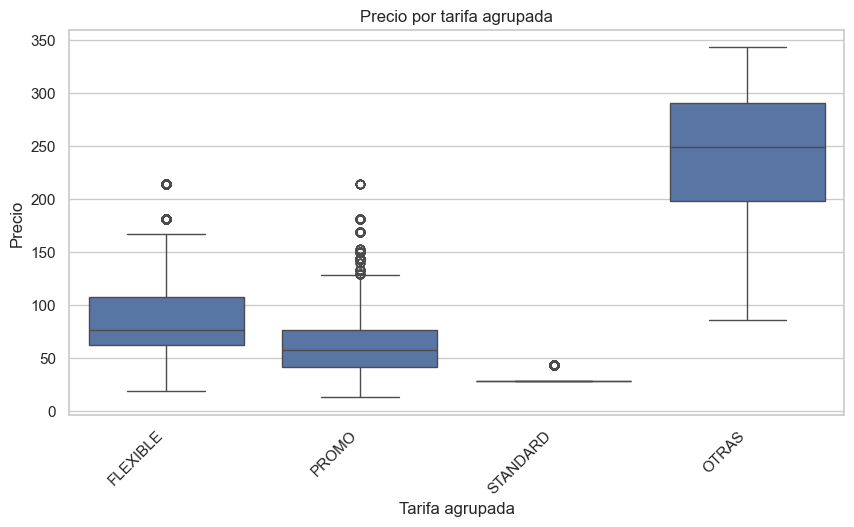

In [126]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_model, x='TIPO_TARIFA_AGRUPADA', y='PRECIO')
plt.title('Precio por tarifa agrupada')
plt.xlabel('Tarifa agrupada')
plt.ylabel('Precio')
plt.xticks(rotation=45, ha='right')
plt.show()


### Precio por clase


In [127]:
price_by_class = (
    df_model
    .groupby('CLASE')
    .agg(
        cantidad=('PRECIO', 'count'),
        precio_medio=('PRECIO', 'mean'),
        precio_mediano=('PRECIO', 'median')
    )
    .sort_values('precio_mediano', ascending=False)
)

price_by_class


,cantidad,precio_medio,precio_mediano
CLASE,,,
CAMA G. CLASE,14,143.11,150.60
TURISTA PLUS,23292,83.85,90.50
PREFERENTESÓLO PLAZA H,258,81.00,87.40
TURISTA PLUSSÓLO PLAZA H,1,80.60,80.60
TURISTASÓLO PLAZA H,1912,88.23,76.30
CAMA TURISTA,240,74.20,74.20
PREFERENTE,30614,76.44,69.40
TURISTA,276894,58.99,55.80
TURISTA CON ENLACE,21288,43.78,40.60


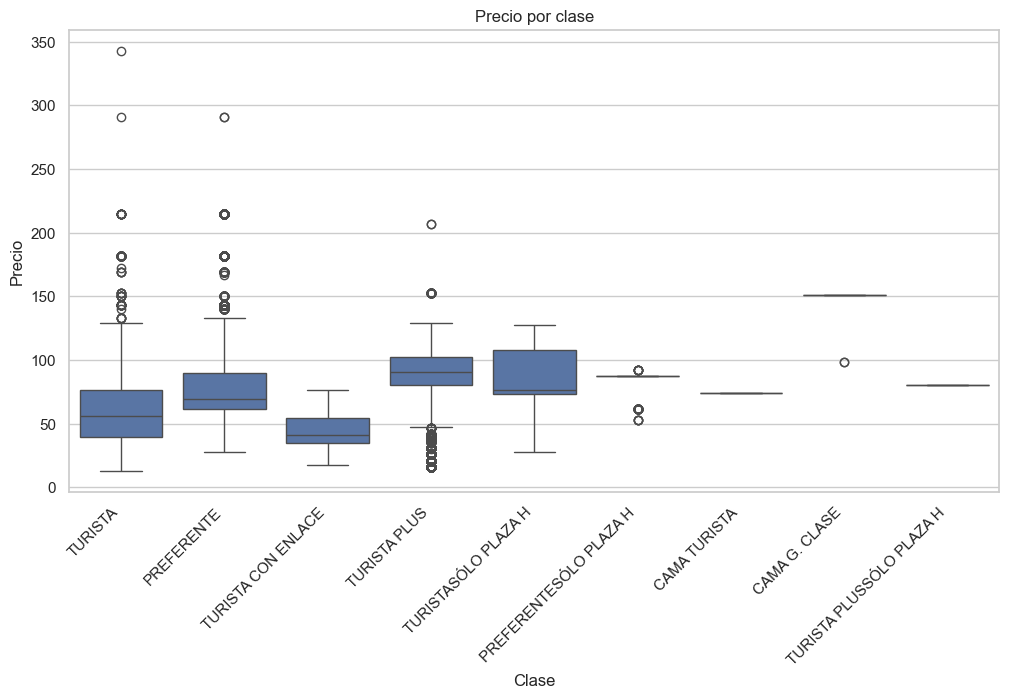

In [128]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_model, x='CLASE', y='PRECIO')
plt.title('Precio por clase')
plt.xlabel('Clase')
plt.ylabel('Precio')
plt.xticks(rotation=45, ha='right')
plt.show()


### Relación entre anticipación de compra y precio


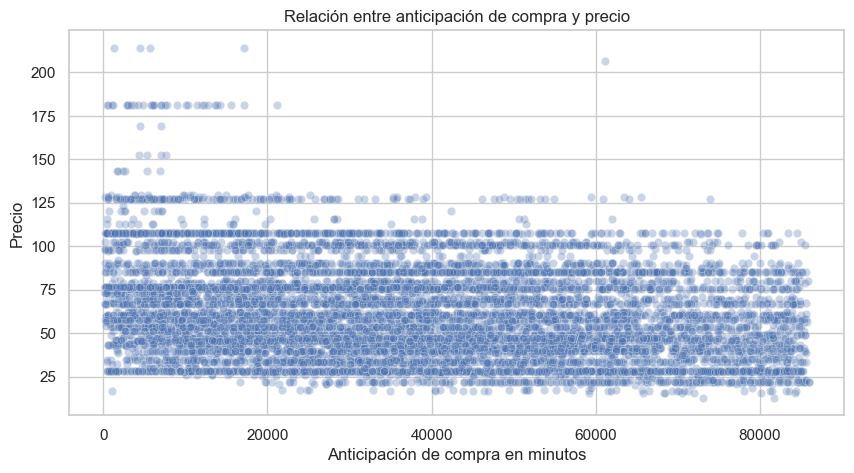

In [129]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df_model.sample(min(10000, len(df_model)), random_state=42),
    x='ANTICIPACION_COMPRA_MIN',
    y='PRECIO',
    alpha=0.3
)
plt.title('Relación entre anticipación de compra y precio')
plt.xlabel('Anticipación de compra en minutos')
plt.ylabel('Precio')
plt.show()


In [130]:
# Agrupar anticipación de compra en intervalos para facilitar el análisis
df_model['ANTICIPACION_BUCKET'] = pd.cut(
    df_model['ANTICIPACION_COMPRA_DIAS'],
    bins=[0, 1, 3, 7, 14, 30, 60, 90, np.inf],
    labels=['0-1 días', '1-3 días', '3-7 días', '7-14 días', '14-30 días', '30-60 días', '60-90 días', '+90 días'],
    include_lowest=True
)

price_by_anticipation = (
    df_model
    .groupby('ANTICIPACION_BUCKET', observed=False)
    .agg(
        cantidad=('PRECIO', 'count'),
        precio_medio=('PRECIO', 'mean'),
        precio_mediano=('PRECIO', 'median')
    )
)

price_by_anticipation


,cantidad,precio_medio,precio_mediano
ANTICIPACION_BUCKET,,,
0-1 días,5891,80.85,76.30
1-3 días,13371,76.42,73.10
3-7 días,27318,70.91,67.20
7-14 días,49810,65.92,62.20
14-30 días,115291,61.54,58.15
30-60 días,142832,55.70,52.45
60-90 días,0,NaN,NaN
+90 días,0,NaN,NaN


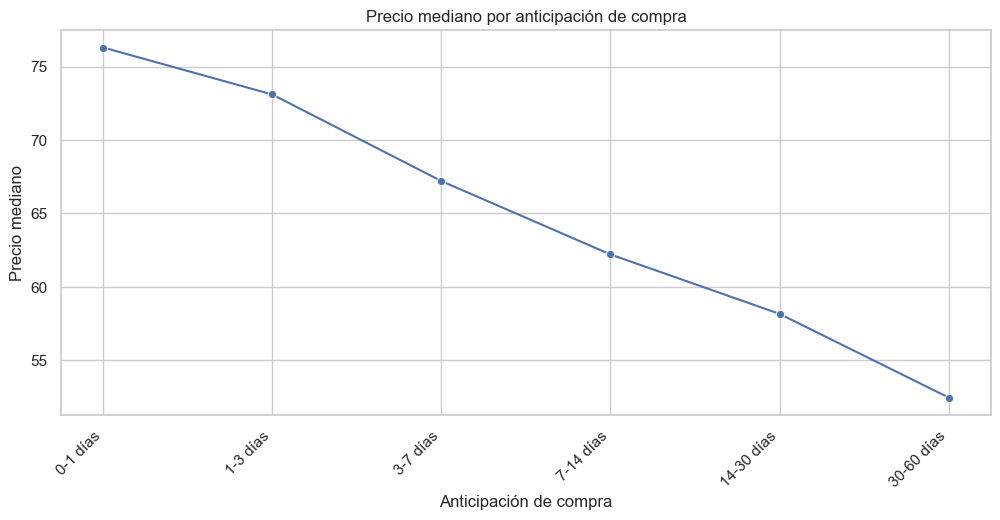

In [131]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=price_by_anticipation.reset_index(), x='ANTICIPACION_BUCKET', y='precio_mediano', marker='o')
plt.title('Precio mediano por anticipación de compra')
plt.xlabel('Anticipación de compra')
plt.ylabel('Precio mediano')
plt.xticks(rotation=45, ha='right')
plt.show()


### Precio según día y hora de salida


In [132]:
price_by_weekday = (
    df_model
    .groupby(['DIA_SEMANA_NUM', 'DIA_SEMANA_SALIDA'])
    .agg(
        cantidad=('PRECIO', 'count'),
        precio_mediano=('PRECIO', 'median')
    )
    .reset_index()
    .sort_values('DIA_SEMANA_NUM')
)

price_by_weekday


,DIA_SEMANA_NUM,DIA_SEMANA_SALIDA,cantidad,precio_mediano
0,0,Monday,53163,57.75
1,1,Tuesday,53783,53.40
2,2,Wednesday,53607,53.40
3,3,Thursday,55773,57.75
4,4,Friday,53053,62.20
5,5,Saturday,37738,55.40
6,6,Sunday,47396,66.75


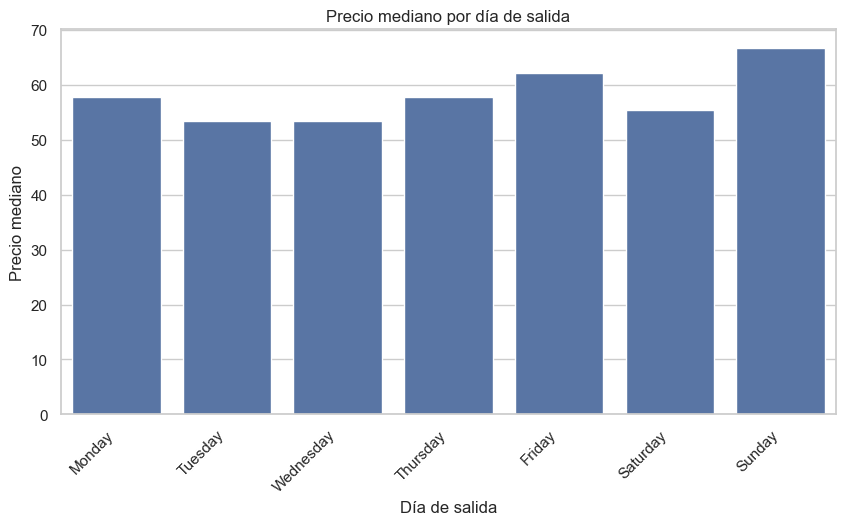

In [133]:
plt.figure(figsize=(10, 5))
sns.barplot(data=price_by_weekday, x='DIA_SEMANA_SALIDA', y='precio_mediano')
plt.title('Precio mediano por día de salida')
plt.xlabel('Día de salida')
plt.ylabel('Precio mediano')
plt.xticks(rotation=45, ha='right')
plt.show()


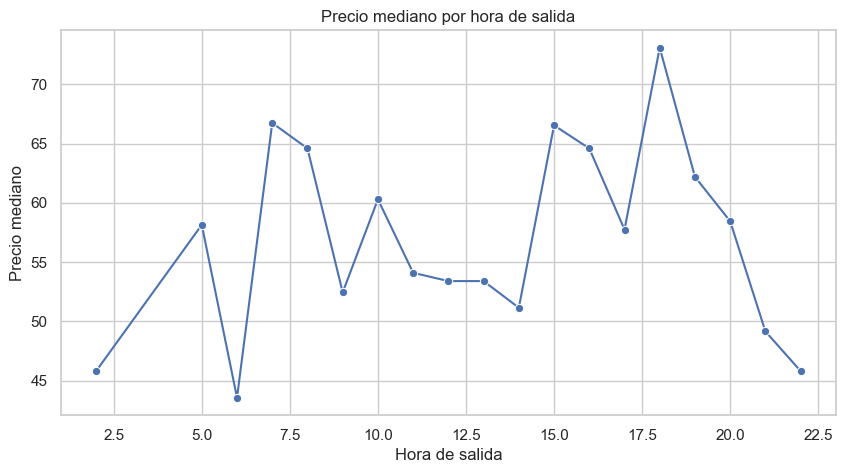

In [134]:
price_by_hour = (
    df_model
    .groupby('HORA_SALIDA')
    .agg(
        cantidad=('PRECIO', 'count'),
        precio_mediano=('PRECIO', 'median')
    )
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=price_by_hour, x='HORA_SALIDA', y='precio_mediano', marker='o')
plt.title('Precio mediano por hora de salida')
plt.xlabel('Hora de salida')
plt.ylabel('Precio mediano')
plt.show()


## 12. Correlación entre variables numéricas


In [135]:
numeric_columns_for_corr = [
    'PRECIO',
    'DURACION_VIAJE_MIN',
    'ANTICIPACION_COMPRA_DIAS',
    'HORA_SALIDA',
    'DIA_SEMANA_NUM',
    'MES_SALIDA',
    'ES_FIN_DE_SEMANA'
]

corr_matrix = df_model[numeric_columns_for_corr].corr()
corr_matrix


,PRECIO,DURACION_VIAJE_MIN,ANTICIPACION_COMPRA_DIAS,HORA_SALIDA,DIA_SEMANA_NUM,MES_SALIDA,ES_FIN_DE_SEMANA
PRECIO,1.00,-0.24,-0.24,0.05,0.08,-0.19,0.04
DURACION_VIAJE_MIN,-0.24,1.00,0.02,-0.18,0.01,-0.00,0.01
ANTICIPACION_COMPRA_DIAS,-0.24,0.02,1.00,0.00,0.03,0.45,0.02
HORA_SALIDA,0.05,-0.18,0.00,1.00,0.09,-0.00,0.08
DIA_SEMANA_NUM,0.08,0.01,0.03,0.09,1.00,0.01,0.77
MES_SALIDA,-0.19,-0.00,0.45,-0.00,0.01,1.00,0.01
ES_FIN_DE_SEMANA,0.04,0.01,0.02,0.08,0.77,0.01,1.00


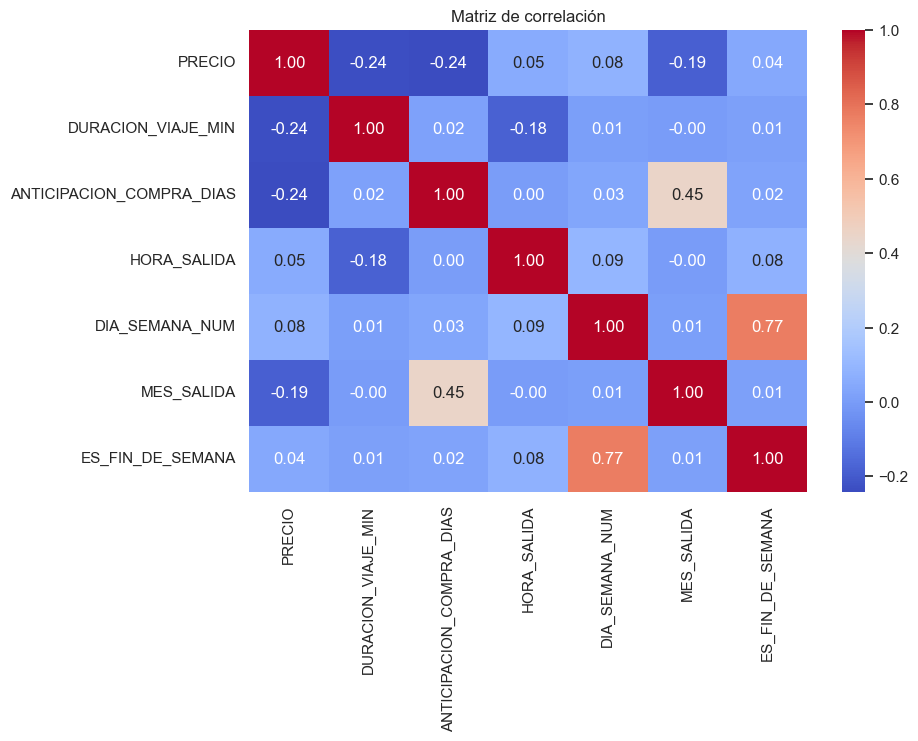

In [136]:
plt.figure(figsize=(9, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()


## 13. Dataset final para modelado

Seleccionamos las columnas finales que podrían usarse para entrenar un modelo predictivo de precios.

Mantenemos también algunas fechas originales para trazabilidad, aunque en un modelo final podrían excluirse o transformarse.


In [137]:
model_columns = [
    'FECHA_CONSULTA',
    'FECHA_INICIO',
    'FECHA_FIN',
    'CIUDAD_ORIGEN',
    'CIUDAD_DESTINO',
    'RUTA',
    'TIPO_TREN',
    'TIPO_TARIFA',
    'TIPO_TARIFA_AGRUPADA',
    'CLASE',
    'DURACION_VIAJE_MIN',
    'ANTICIPACION_COMPRA_DIAS',
    'HORA_SALIDA',
    'DIA_SEMANA_SALIDA',
    'DIA_SEMANA_NUM',
    'MES_SALIDA',
    'ES_FIN_DE_SEMANA',
    'PRECIO'
]

df_model_final = df_model[model_columns].copy()

df_model_final.head()


,FECHA_CONSULTA,FECHA_INICIO,FECHA_FIN,CIUDAD_ORIGEN,CIUDAD_DESTINO,RUTA,TIPO_TREN,TIPO_TARIFA,TIPO_TARIFA_AGRUPADA,CLASE,DURACION_VIAJE_MIN,ANTICIPACION_COMPRA_DIAS,HORA_SALIDA,DIA_SEMANA_SALIDA,DIA_SEMANA_NUM,MES_SALIDA,ES_FIN_DE_SEMANA,PRECIO
0,2019-05-25 01:43:03,2019-06-28 20:36:00,2019-06-28 23:14:00,SEVILLA,MADRID,SEVILLA - MADRID,ALVIA,FLEXIBLE,FLEXIBLE,TURISTA,158.00,34.79,20,Friday,4,6,0,67.20
1,2019-06-22 13:05:11,2019-07-14 10:00:00,2019-07-14 13:10:00,BARCELONA,MADRID,BARCELONA - MADRID,AVE,FLEXIBLE,FLEXIBLE,TURISTA,190.00,21.87,10,Sunday,6,7,1,107.70
2,2019-04-17 06:24:03,2019-05-23 13:40:00,2019-05-23 16:10:00,SEVILLA,MADRID,SEVILLA - MADRID,AVE,PROMO,PROMO,TURISTA,150.00,36.30,13,Thursday,3,5,0,47.30
3,2019-05-10 21:21:59,2019-05-29 14:50:00,2019-05-29 22:30:00,VALENCIA,MADRID,VALENCIA - MADRID,REGIONAL,ADULTO IDA,STANDARD,TURISTA,460.00,18.73,14,Wednesday,2,5,0,28.35
4,2019-05-09 19:43:37,2019-06-26 13:25:00,2019-06-26 16:24:00,MADRID,BARCELONA,MADRID - BARCELONA,AVE-TGV,PROMO,PROMO,TURISTA,179.00,47.74,13,Wednesday,2,6,0,66.75


In [138]:
# Revisión final de calidad del dataset de modelado
final_quality_summary = pd.DataFrame({
    'dtype': df_model_final.dtypes.astype(str),
    'null_count': df_model_final.isnull().sum(),
    'null_percentage': (df_model_final.isnull().mean() * 100).round(2),
    'unique_values': df_model_final.nunique(dropna=False)
}).sort_values('null_percentage', ascending=False)

final_quality_summary


,dtype,null_count,null_percentage,unique_values
FECHA_CONSULTA,datetime64[ns],0,0.00,214461
FECHA_INICIO,datetime64[ns],0,0.00,17496
ES_FIN_DE_SEMANA,int64,0,0.00,2
MES_SALIDA,int32,0,0.00,7
DIA_SEMANA_NUM,int32,0,0.00,7
DIA_SEMANA_SALIDA,object,0,0.00,7
HORA_SALIDA,int32,0,0.00,19
ANTICIPACION_COMPRA_DIAS,float64,0,0.00,340159
DURACION_VIAJE_MIN,float64,0,0.00,98
CLASE,string,0,0.00,9


In [139]:
print(f'Final dataset rows: {df_model_final.shape[0]:,}')
print(f'Final dataset columns: {df_model_final.shape[1]:,}')


Final dataset rows: 354,513
Final dataset columns: 18


## 14. Exportación del dataset limpio


In [140]:
OUTPUT_PATH = 'trenmax_cleaned.csv'

df_model_final.to_csv(OUTPUT_PATH, index=False)

print(f'Clean dataset exported to: {OUTPUT_PATH}')


Clean dataset exported to: trenmax_cleaned.csv


## 15. Conclusiones

El dataset final queda preparado para una etapa posterior de modelado predictivo.

Principales mejoras aplicadas:

1. Conversión correcta de fechas.
2. Eliminación de duplicados exactos.
3. Normalización de variables categóricas.
4. Tratamiento explícito de nulos categóricos con `DESCONOCIDO`.
5. Exclusión de registros sin precio válido para modelado.
6. Creación de variables relevantes como `RUTA`, `DURACION_VIAJE_MIN` y `ANTICIPACION_COMPRA_DIAS`.
7. Agrupación de tarifas en categorías más interpretables.
8. Análisis del precio por ruta, tren, tarifa, clase, anticipación, día y hora.
9. Exportación de un dataset limpio y listo para modelado.
